# Accessible Box Plots

This notebook is a standalone teaching resource for creating accessible box plots with Matplotlib and describing it with MatplotAlt.

## What this graph is used for

Box plots summarize a distribution using the median, quartiles, variability, and possible outliers.

## How to make it more accessible

For accessibility, contextualize what the values represent, label measurement units, use a descriptive title and readable text, and include grid lines when they help users estimate values. A meaningful category label also makes the statistical summary easier to interpret non-visually.

## Setup

This notebook requires `matplotlib` and `matplotalt`; the heatmap notebook also uses `numpy`. If MatplotAlt is not installed, install it in your Python environment with `pip install matplotalt`.


### MatplotAlt description levels used in this notebook

The notebook generates descriptions at all four description levels using MatplotAlt:

- **Level 1:** axes and visual encodings such as color.
- **Level 2:** Level 1 plus statistics about the data.
- **Level 3:** Level 2 plus trends and relationships/correlation where supported.
- **Level 4:** broader contextual description. MatplotAlt's documentation indicates that Level 4 is available through its API/VLM functions, so this notebook uses `show_with_api_alt` for Level 4 and reads the API key from the `OPENAI_API_KEY` environment variable.

For Levels 1–3, the notebook uses the rule-based `show_with_alt` function. For Level 4, set an `OPENAI_API_KEY` in the environment before running the description cell.


In [5]:
import os
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotalt import show_with_alt, show_with_api_alt

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")


def show_all_description_levels(build_plot, 
                                chart_type=None,
                                max_rule_based_level=3,
):
    """Plot the figure and display MatplotAlt descriptions at Levels 1–4."""

    # MatplotAlt's rule-based descriptions support Levels 1–3.
    for level in range(1, max_rule_based_level + 1):
        plt.close("all")
        build_plot()
        display(Markdown(f"#### Level {level} description"))
        kwargs = {
            "desc_level": level, 
            "methods": ["markdown"],
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_alt(**kwargs)

    # Level 4 uses MatplotAlt's API/VLM description function.
    plt.close("all")
    display(Markdown("#### Level 4 description"))
    if OPENAI_API_KEY:
        build_plot()
        kwargs = {
            "methods": ["markdown"],
            "use_starter_alt_in_prompt": True,
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_api_alt(OPENAI_API_KEY, **kwargs)
    else:
        display(Markdown(
            "**Level 4 was not generated because `OPENAI_API_KEY` is not set.** "
            "Set that environment variable and rerun this cell to generate the broader-context "
            "Level 4 description with MatplotAlt."
        ))


## Accessible example

The code below showcases an accessibility-aware example of a box plot also presented in the Guidelines document.

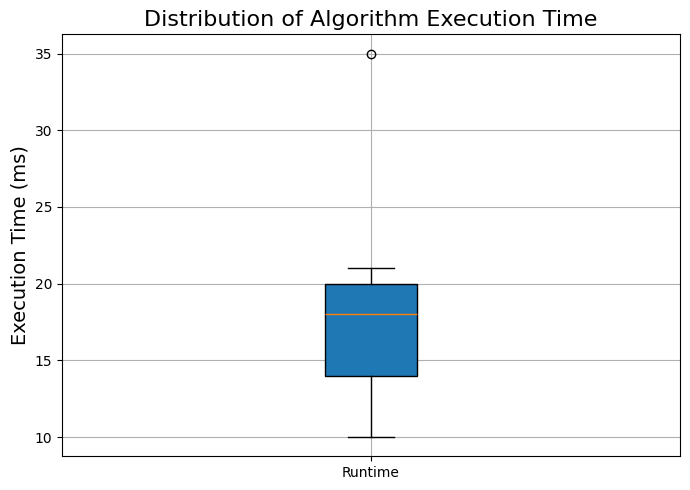

In [3]:
import matplotlib.pyplot as plt

algorithm_runtime = [10, 12, 14, 15, 18, 19, 20, 21, 35]

plt.figure(figsize=(7, 5))

plt.boxplot(
    algorithm_runtime,
    tick_labels=["Runtime"],
    patch_artist=True
)

plt.ylabel("Execution Time (ms)", fontsize=14)
plt.title("Distribution of Algorithm Execution Time", fontsize=16)

plt.grid(True)

plt.tight_layout()
plt.show()


### MatplotAlt descriptions for the worked example

The next cell recreates the same graph and generates Levels 1–3 with `show_with_alt`. It generates Level 4 with `show_with_api_alt` when `OPENAI_API_KEY` is available.

#### Level 1 description

A boxplot titled 'distribution of algorithm execution time'. The x-axis ranges from runtime to runtime using a categorical scale and execution time (ms) is plotted on the y-axis from 5 to 40 using a linear scale.

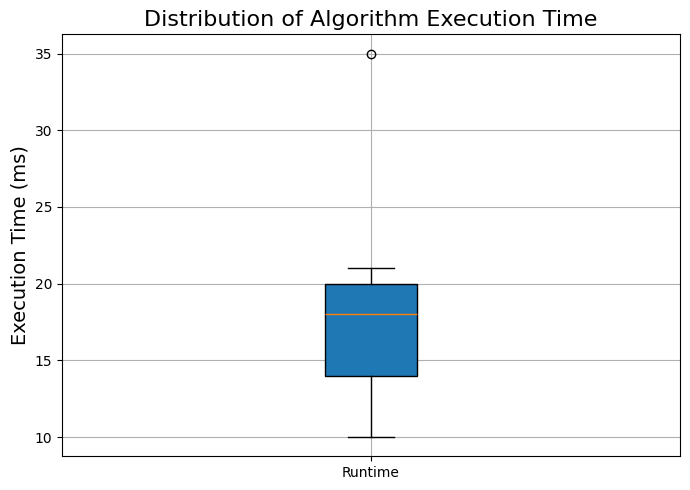

#### Level 2 description

A boxplot titled 'distribution of algorithm execution time'. The x-axis ranges from runtime to runtime using a categorical scale and execution time (ms) is plotted on the y-axis from 5 to 40 using a linear scale. Boxplot runtime has a median of 18.0, an interquartile range of 6, and 1 outlier at y=35.

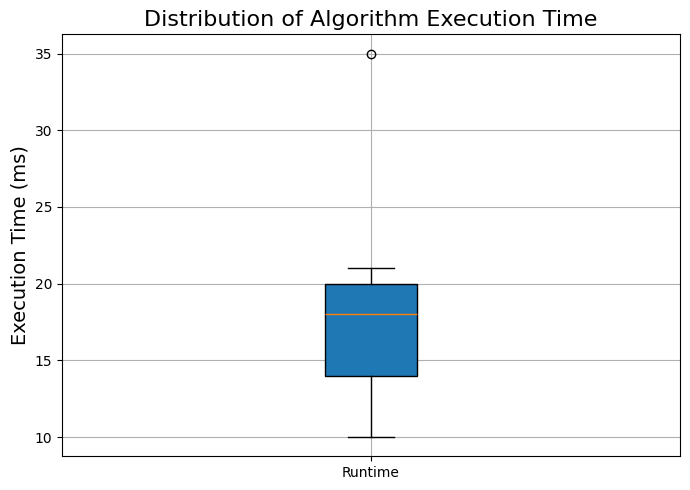

#### Level 4 description

**Level 4 was not generated because `OPENAI_API_KEY` is not set.** Set that environment variable and rerun this cell to generate the broader-context Level 4 description with MatplotAlt.

In [6]:
def build_example_plot():
    algorithm_runtime = [10, 12, 14, 15, 18, 19, 20, 21, 35]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        algorithm_runtime,
        tick_labels=["Runtime"],
        patch_artist=True
    )

    plt.ylabel("Execution Time (ms)", fontsize=14)
    plt.title("Distribution of Algorithm Execution Time", fontsize=16)

    plt.grid(True)
    plt.tight_layout()


show_all_description_levels(
    build_example_plot,
    chart_type="boxplot",
    max_rule_based_level=2,
)


## Reusable accessible template

Replace the placeholder data and text with your own values. Keep the descriptive labels, meaningful title, readable text, high-contrast/redundant encodings where relevant, and the other accessibility features shown.

In [ ]:
# Replace the placeholder values and text below with your own data.
values = [8, 10, 11, 13, 14, 15, 17, 18, 26]
category_label = "Measurement"

y_axis_label = "Measured value (unit)"
graph_title = "Distribution of the measured values"


def build_accessible_box_plot():
    plt.figure(figsize=(7, 5))

    plt.boxplot(
        values,
        tick_labels=[category_label],
        patch_artist=True
    )

    plt.ylabel(y_axis_label, fontsize=14)
    plt.title(graph_title, fontsize=16)

    plt.grid(True)
    plt.tight_layout()


build_accessible_box_plot()
plt.show()


### MatplotAlt descriptions for the template graph

Run the next cell after adapting the placeholders. It generates all four description levels in the same way as the shown example.

In [ ]:
show_all_description_levels(
    build_example_plot,
    chart_type="boxplot",
    max_rule_based_level=2,
)